In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#### The question we want to answer is whether professional tennis athletes are strongly influenced by the monetary prize from each tournament and they are trying harder to win when the prize is higher. To measure effort we calculate the number of sets from each game during the final round for each tournament as well as the total financial reward for the winner.

In [2]:
PATH = "data/tennis/"
tennis = pd.read_csv(PATH+"atp_tennis.csv")
prize = pd.read_csv(PATH + "Mens_Tennis_Grand_Slam_Winner.csv")

prize.head()

,YEAR,TOURNAMENT,WINNER,RUNNER-UP,WINNER_NATIONALITY,WINNER_ATP_RANKING,RUNNER-UP_ATP_RANKING,WINNER_LEFT_OR_RIGHT_HANDED,TOURNAMENT_SURFACE,WINNER_PRIZE
0,2023,Australian Open,Novak Djokovic,Stefanos Tsitsipas,Serbian,1.0,3.0,right,Plexicushion Prestige,2050000.0
1,2022,U.S. Open,Carlos Alcaraz,Casper Rudd,Spanish,2.0,5.0,right,DecoTurf - outdoors,2600000.0
2,2022,Wimbledon,Novak Djokovic,Nick Kyrgios,Serbian,NaN,25.0,right,Grass / Outdoor,2507460.0
3,2022,French Open,Rafael Nadal,Casper Rudd,Spanish,5.0,8.0,left,Clay,1870000.0
4,2022,Australian Open,Rafael Nadal,Daniil Medvedev,Spanish,5.0,2.0,left,Plexicushion Prestige,4400000.0


In [3]:
prize_tourn = prize["TOURNAMENT"].unique()

# Cleaning the data 
tennis_tourn = tennis["Tournament"].unique()
prize["Tournament"] = prize["TOURNAMENT"].replace(r"\s*\(.*?\)", "", regex=True)
awards = prize[['Tournament', 'YEAR', 'WINNER_PRIZE']]
awards['Year'] = awards['YEAR']
tennis['Date'] = pd.to_datetime(tennis["Date"])
tennis["Year"] = tennis['Date'].dt.year
print(prize['Tournament'].unique())


<StringArray>
['Australian Open', 'U.S. Open', 'Wimbledon', 'French Open']
Length: 4, dtype: str


In [4]:
tennis_clean = tennis[tennis['Tournament'].isin(awards['Tournament'])].reset_index()
tennis_clean = tennis_clean[['Tournament', 'Series', 'Year', 'Round', 'Score']]
tennis_clean['Sets'] = tennis_clean['Score'].str.split().str.len()
tennis_clean.head()

,Tournament,Series,Year,Round,Score,Sets
0,Australian Open,Grand Slam,2000,1st Round,6-4 7-6 7-5,3
1,Australian Open,Grand Slam,2000,1st Round,3-6 6-7 2-6,3
2,Australian Open,Grand Slam,2000,1st Round,6-2 4-6 6-7 6-3 6-0,5
3,Australian Open,Grand Slam,2000,1st Round,0-6 2-6 2-6,3
4,Australian Open,Grand Slam,2000,1st Round,7-5 7-6 4-6 2-6 6-8,5


In [5]:
# Looking data only for the final matches 
all_finals = tennis_clean[tennis_clean['Round']=='The Final']
all_finals = all_finals.drop(columns=['Round', 'Score', 'Series'])
all_finals_combined = all_finals.merge(awards, how='left', on=['Tournament', 'Year'])
all_finals_combined = all_finals_combined.dropna(axis=0)
all_finals_combined['Prize'] = all_finals_combined['WINNER_PRIZE'].astype(float)
all_finals_combined = all_finals_combined.drop(columns=['WINNER_PRIZE', 'YEAR'])
all_finals_combined

,Tournament,Year,Sets,Prize
0,Australian Open,2000,4,755000.0
1,French Open,2000,4,4240000.0
2,Wimbledon,2000,4,477500.0
3,Australian Open,2001,3,830500.0
4,French Open,2001,4,4538000.0
...,...,...,...,...
64,Wimbledon,2021,4,1700000.0
65,Australian Open,2022,5,4400000.0
66,French Open,2022,3,1870000.0
67,Wimbledon,2022,4,2507460.0


In [6]:
avg_perf = all_finals_combined.groupby('Year')[['Sets', 'Prize']].mean().reset_index()
avg_perf['Prize'] = avg_perf['Prize'].round(1)
avg_perf

,Year,Sets,Prize
0,2000,4.000000,1824166.7
1,2001,4.000000,1956166.7
2,2002,3.666667,768333.3
3,2003,3.000000,847616.7
4,2004,4.000000,887500.0
5,2005,3.666667,905540.0
6,2006,4.000000,938333.3
7,2007,4.000000,993666.7
8,2008,4.000000,1040000.0
9,2009,4.333333,1303333.3


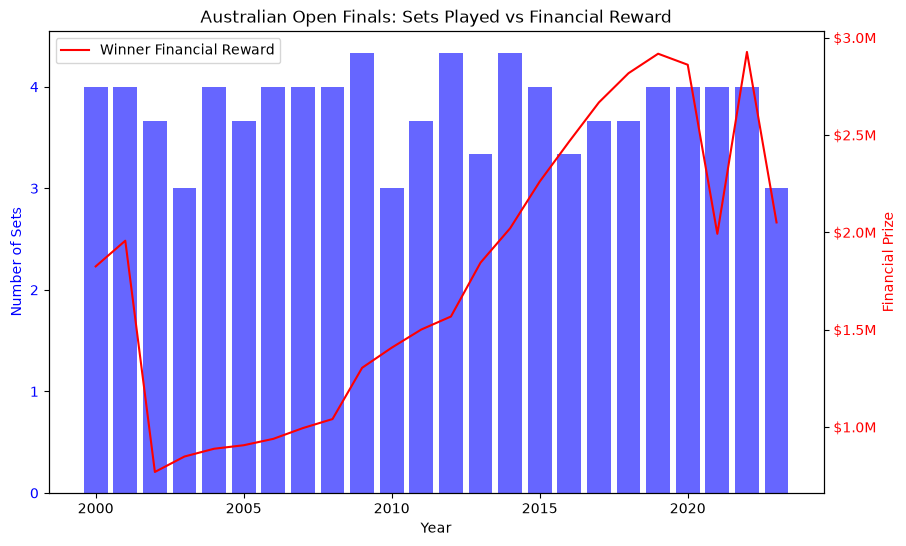

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_perf['Year'], avg_perf['Sets'], color='blue', alpha=0.6, label='Number of sets in the final')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Sets', color = 'blue')
ax.tick_params(axis='y', labelcolor='blue')

ax2 = ax.twinx()
line = ax2.plot(avg_perf['Year'], avg_perf['Prize'], color='red', label='Winner Financial Reward')
ax2.set_ylabel('Financial Prize', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x*1e-6:.1f}M'))

plt.legend()
plt.title('Australian Open Finals: Sets Played vs Financial Reward')
plt.show()

#### Based on analysis from the last 24 years from 